# Correlation Analyses 

This notebook uses the features data from the folder data/processed and conducts a correlation analyses. 

In [8]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
import numpy as np 
from ydata_profiling import ProfileReport
from c08_farming_exit import config, features, data_cleaning, mappings, feature_engineering


import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# #In case you want to run Stata in a cell using the magic command %%stata, initialize it first!
# from c08_farming_exit.stata_utils import init_stata
# init_stata()

## 1. Import features data

In [10]:
df = pd.read_csv(config.PROCESSED_DATA_DIR / "features_data.csv")

## 2. Prepare Data

In [11]:
#checking the profit and cost-ratio data makes me drop information on lifestock income as there is a lot of negative profit!
dropping = ['livestock_profit_last_12_months', 'livestock_cost_ratio']
df = df.drop(columns=dropping)

df['primary_activity_employed_work_share'] = df['primary_activity_self_employed_work_share'] + df['primary_activity_wage_employed_work_share']

In [12]:
target_cols =['empl_category', 
              'aspiration_continue_farming',
              'off_farm_hours_annual_share',
              'on_farm_hours_annual_share',
              'off_farm_income_annual_share',
              'on_farm_income_annual_share',
              'primary_activity_farm_work_share'
              'primary_activity_employed_work_share',]
geo_cols = ['country', 'district', 'enumeration_area', 'region']
identification_cols = ['personal_id',  'interview_key', 'members_id']
df = df.dropna(subset=geo_cols + identification_cols)

## 3. Run XGBoost

In [ ]:
cols_to_keep = [
# 'district',
 'respondant_relation_to_head',
 'gender',
 'relation_to_head',
 'age',
 #'ethnic_group',
 #'religion',
 'years_of_schooling',
 #'enumeration_area',
 #'region',
 #'personal_id',
 'land_cropland_ownership_status',
 'land_residential_ownership_status',
 'land_used_as_collateral',
 'land_number_of_plots',
 'land_size_cropland_acres',
 'land_size_fallow_acres',
 'land_size_agroforestry_forestry_acres',
 'land_size_pasture_acres',
 'land_size_residential_acres',
 'land_size_lodge_camp_acres',
 'grazing_distance_in_min',
#  'grazing_time_in_min',
#  'grazing_time_hours_per_day',
 'grazing_land_ownership_status',
 'grazing_land_number_hh_sharing',
 'grazing_land_permit',
 'grazing_land_permit_price',
 'grazing_land_use_duration_in_years',
#  'livestock_products_sold_last_12_months',
#  'livestock_products_sold_meat',
#  'livestock_products_sold_milk',
#  'livestock_products_sold_cheese',
#  'livestock_products_sold_yogurt',
#  'livestock_products_sold_wool',
#  'livestock_products_sold_honey_wax',
#  'livestock_products_sold_eggs',
#  'livestock_products_buyer',
#  'livestock_products_market_type',
 'livestock_market_distance_in_km',
#  'livestock_income_last_12_months',
 'livestock_contract',
 'house_room_number',
 'house_roof_material',
 'house_wall_material',
 'house_floor_material',
 'house_water_source',
 'house_toilet_type',
 'house_energy_source',
 'house_energy_source_for_cooking',
 'house_energy_source_for_lighting',
 'internet_access',
 'internet_access_at_home',
 'mobile_money_access',
 'membership_farmers_group',
 'membership_agricultural_cooperative',
 'worry_about_job_loss_or_economic_livelihood',
 'sufficent_food_number_of_month',
 'road_type',
 'road_condition',
 'road_distance_in_minutes',
 'market_output_distance_in_km',
 'market_input_distance_in_km',
 'market_type',
 'crop_contract',
#  'crop_contract_crop_type',
 'subsidy',
#  'subsidy_type_seeds',
#  'subsidy_type_fertilizer',
#  'subsidy_type_agro_chemicals',
#  'subsidy_type_interest_free_loan',
#  'subsidy_supplier_government',
#  'subsidy_supplier_ngos',
#  'subsidy_supplier_company',
#  'crop_harvested',
#  'crop_sale',
#  'crop_home_consumption',
#  'crop_storage',
#  'crop_buyer_market',
#  'crop_buyer_trader',
#  'crop_buyer_cooperative',
#  'crop_buyer_commercial_farm',
#  'crop_buyer_hospitality',
#  'crop_buyer_government',
#  'crop_organic_fertilizer',
#  'crop_inorganic_fertilizer',
#  'crop_pesticides',
#  'crop_tractor',
#  'crop_sale_revenue_last_12_months',
#  'crop_type_diversity',
#  'livestock_number_owned_tlu',
#  'livestock_number_lost_disease_theft_tlu',
#  'livestock_number_lost_wildlife_attack_tlu',
#  'livestock_revenue_sold',
#  'livestock_diversity',
 'asset_value',
 'asset_diversity',
 'other_income_amount_annual',
 'shock_type_affected_last_12_months_crop_failure',
 'shock_type_affected_last_12_months_drought',
 'shock_type_affected_last_12_months_floods',
 'shock_type_affected_last_12_months_illness_death',
 'shock_type_affected_last_12_months_livestock_loss',
 'shock_type_affected_last_12_months_other',
 'shock_type_affected_last_12_months_price_shock',
 'shock_coping_strategy_relatives_friends',
 'shock_coping_strategy_government',
 'shock_coping_strategy_food_reduction',
 'shock_coping_strategy_changed_cropping_practices',
 'shock_coping_strategy_more_employment',
 'shock_coping_strategy_hh_member_migration',
 'shock_coping_strategy_savings',
 'shock_coping_strategy_insurance',
 'shock_coping_strategy_credit',
 'shock_coping_strategy_sold_hh_assets',
 'shock_coping_strategy_sold_livestock',
 'shock_coping_strategy_migration',
 'shock_future_likelihood_change_income_source',
 #'country',
 #'sector_off_farm_empl_last_12_months',
 #'empl_type',
 #'self_empl_registered',
 #'self_empl_location',
 #'self_empl_number_of_employees',
 #'self_empl_years_experience_in_years',
 #'self_empl_supported_by_governance',
 #'wage_empl_location',
 #'wage_empl_type',
 #'benefits_housing',
 #'benefits_meals',
 #'benefits_transportation',
 #'uncompensated_work',
 #'work_accident',
 #'paternity_maternity_leave',
 #'health_insurance',
 #'unprotected_dangerous_products',
 #'paid_annual_leave',
 #'paid_sick_leave',
 #'contract_status',
 #'job_search',
 #'training_received',
 #'duration_in_years',
 #'job_satisfaction',
 #'farm_empl_last_12_months',
 #'farm_empl_crops_years_experience_in_years',
 #'farm_empl_livestock_years_experience_in_years',
 'migrant_last_12_months',
 'current_migrant',
 'migration_intention_next_12_months',
 'remittance_amount_sent_last_12_months',
 'beans_allocated_to_empl_occupation',
#  'aspired_occupation_5_years_ahead',
 'life_satisfaction',
#  'aspiration_continue_farming',
 'agriculture_loan_last_5_years',
 'agriculture_loan_amount',
 'agriculture_loan_lender_bank',
 'agriculture_loan_lender_credit_union',
 'agriculture_loan_lender_private_lender',
 'agriculture_loan_lender_government',
 'agriculture_loan_lender_ngos',
#  'child_aspiration_continue_farming',
#  'primary_activity_domestic_and_care_work_share',
#  'primary_activity_farm_work_share',
#  'primary_activity_mobility_education_share',
#  'primary_activity_personal_time_leisure_share',
#  'primary_activity_self_employed_work_share',
#  'primary_activity_wage_employed_work_share',
#  'interview_key',
#  'members_id',
#  'empl_category',
 #'cash_crop_hours_per_year',
 #'food_crop_hours_per_year',
 #'livestock_hours_per_year',
 #'farm_empl_hours_per_year',
 #'self_empl_hours_per_year',
 #'wage_empl_permanent_hours_per_year',
 #'wage_empl_seasonal_casual_hours_per_year',
 #'total_work_hours_per_year',
 #'self_empl_hours_annual_share',
 #'wage_empl_permanent_hours_annual_share',
 #'wage_empl_seasonal_casual_hours_annual_share',
 #'off_farm_hours_per_year',
 'off_farm_hours_annual_share',
 #'on_farm_hours_annual_share',
 #'farm_empl_wage_per_hour',
 #'farm_empl_income_per_year',
 #'self_empl_wage_per_hour',
 #'self_empl_income_per_year',
 #'wage_empl_permanent_wage_per_hour',
 #'wage_empl_permanent_income_per_year',
 #'wage_empl_seasonal_casual_wage_per_hour',
 #'wage_empl_seasonal_casual_income_per_year',
 #'total_income_per_year',
 #'self_empl_income_annual_share',
 #'wage_empl_permanent_income_annual_share',
 #'wage_empl_seasonal_casual_income_annual_share',
 #'off_farm_income_per_year',
#  'off_farm_income_annual_share',
#  'on_farm_income_annual_share',
 #'self_empl_wage_premium_vs_farm',
 #'wage_empl_permanent_wage_premium_vs_farm',
 #'wage_empl_seasonal_casual_wage_premium_vs_farm',
 #'main_use_invest_in_own_business_top_3',
 #'main_use_food_top_3',
 #'main_use_education_top_3',
 #'main_use_health_top_3',
 #'main_use_housing_furniture_top_3',
 #'main_use_transportation_top_3',
 #'main_use_entertainment_top_3',
 #'self_empl_obstacle_index',
 #'self_empl_finance_constr_index',
 #'self_empl_loan_source_index',
 #'self_empl_push_motivation_index',
 #'self_empl_pull_motivation_index',
 'hh_members_count',
 #'hh_members_only_farm_share',
 #'hh_members_hybrid_share',
 #'hh_members_fully_off_farm_share',
 'hh_optimism_index',
 'hh_sentiment_index',
#  'grazing_land_challenges_index',
#  'livestock_exp_last_12_months',
#  'crop_exp_last_12_months',
#  'crop_profit_last_12_months',
#  'crop_cost_ratio',
#  'crop_sale_revenue_per_acre',
#  'crop_profit_per_acre',
#  'primary_activity_employed_work_share'
 ]

df = df[cols_to_keep]

In [14]:
# # --- target ---
# target = "empl_category"
# df = df.dropna(subset=[target])  # can't train on unlabeled rows
# # --- drop columns that leak the target or don't belong as features ---
# # empl_type & farm_empl_last_12_months are literally used to construct empl_category (see 02_feature_engineering.ipynb, cell c8810dc3)
# # hh_members_*_share are aggregated from empl_category itself

# X = df.drop(columns=[target], errors="ignore")
# # For empl_category (only_farm, hybrid, fully_off_farm), alphabetical order gives:
# # fully_off_farm: 0, hybrid: 1, only_farm: 2
# y = LabelEncoder().fit_transform(df[target])

# # --- one-hot encode categoricals, leave everything else (incl. NaNs) as is ---
# X = pd.get_dummies(X, dummy_na=True)

# X = X.drop(columns=["sector_off_farm_empl_last_12_months_nan"], errors="ignore")


# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # --- train with standard hyperparameters ---
# model = XGBClassifier(random_state=42)
# model.fit(X_train, y_train)

# print("Test accuracy:", model.score(X_test, y_test))

# # --- feature importance plot, top 100 ---
# importances = pd.Series(model.feature_importances_, index=X.columns)
# top100 = importances.sort_values(ascending=False).head(250)

# fig, ax = plt.subplots(figsize=(8, 24))
# ax.barh(top100.index[::-1], top100.values[::-1], color="#4C72B0", height=0.6)
# ax.set_xlabel("Feature importance")
# ax.set_title(f"Top 100 XGBoost feature importances — target: {target}")
# ax.grid(axis="x", color="#dddddd", linewidth=0.5, zorder=0)
# ax.set_axisbelow(True)
# fig.tight_layout()
# plt.show()

In [16]:
cols_to_keep = [
# 'district',
#  'respondant_relation_to_head',
#  'gender',
#  'relation_to_head',
#  'age',
 #'ethnic_group',
 #'religion',
#  'years_of_schooling',
 #'enumeration_area',
 #'region',
 #'personal_id',
 'land_cropland_ownership_status',
 'land_residential_ownership_status',
 'land_used_as_collateral',
 'land_number_of_plots',
 'land_size_cropland_acres',
 'land_size_fallow_acres',
 'land_size_agroforestry_forestry_acres',
 'land_size_pasture_acres',
 'land_size_residential_acres',
 'land_size_lodge_camp_acres',
#  'grazing_distance_in_min',
#  'grazing_time_in_min',
#  'grazing_time_hours_per_day',
 'grazing_land_ownership_status',
 'grazing_land_number_hh_sharing',
 'grazing_land_permit',
 'grazing_land_permit_price',
 'grazing_land_use_duration_in_years',
#  'livestock_products_sold_last_12_months',
#  'livestock_products_sold_meat',
#  'livestock_products_sold_milk',
#  'livestock_products_sold_cheese',
#  'livestock_products_sold_yogurt',
#  'livestock_products_sold_wool',
#  'livestock_products_sold_honey_wax',
#  'livestock_products_sold_eggs',
#  'livestock_products_buyer',
#  'livestock_products_market_type',
#  'livestock_market_distance_in_km',
#  'livestock_income_last_12_months',
#  'livestock_contract',
#  'house_room_number',
#  'house_roof_material',
#  'house_wall_material',
#  'house_floor_material',
#  'house_water_source',
#  'house_toilet_type',
#  'house_energy_source',
#  'house_energy_source_for_cooking',
#  'house_energy_source_for_lighting',
 'internet_access',
 'internet_access_at_home',
 'mobile_money_access',
 'membership_farmers_group',
 'membership_agricultural_cooperative',
 'worry_about_job_loss_or_economic_livelihood',
#  'sufficent_food_number_of_month',
#  'road_type',
#  'road_condition',
#  'road_distance_in_minutes',
#  'market_output_distance_in_km',
#  'market_input_distance_in_km',
#  'market_type',
#  'crop_contract',
#  'crop_contract_crop_type',
#  'subsidy',
#  'subsidy_type_seeds',
#  'subsidy_type_fertilizer',
#  'subsidy_type_agro_chemicals',
#  'subsidy_type_interest_free_loan',
#  'subsidy_supplier_government',
#  'subsidy_supplier_ngos',
#  'subsidy_supplier_company',
#  'crop_harvested',
#  'crop_sale',
#  'crop_home_consumption',
#  'crop_storage',
#  'crop_buyer_market',
#  'crop_buyer_trader',
#  'crop_buyer_cooperative',
#  'crop_buyer_commercial_farm',
#  'crop_buyer_hospitality',
#  'crop_buyer_government',
#  'crop_organic_fertilizer',
#  'crop_inorganic_fertilizer',
#  'crop_pesticides',
#  'crop_tractor',
#  'crop_sale_revenue_last_12_months',
#  'crop_type_diversity',
#  'livestock_number_owned_tlu',
#  'livestock_number_lost_disease_theft_tlu',
#  'livestock_number_lost_wildlife_attack_tlu',
#  'livestock_revenue_sold',
#  'livestock_diversity',
#  'asset_value',
#  'asset_diversity',
 'other_income_amount_annual',
#  'shock_type_affected_last_12_months_crop_failure',
#  'shock_type_affected_last_12_months_drought',
#  'shock_type_affected_last_12_months_floods',
#  'shock_type_affected_last_12_months_illness_death',
#  'shock_type_affected_last_12_months_livestock_loss',
#  'shock_type_affected_last_12_months_other',
#  'shock_type_affected_last_12_months_price_shock',
#  'shock_coping_strategy_relatives_friends',
#  'shock_coping_strategy_government',
#  'shock_coping_strategy_food_reduction',
#  'shock_coping_strategy_changed_cropping_practices',
#  'shock_coping_strategy_more_employment',
#  'shock_coping_strategy_hh_member_migration',
#  'shock_coping_strategy_savings',
#  'shock_coping_strategy_insurance',
#  'shock_coping_strategy_credit',
#  'shock_coping_strategy_sold_hh_assets',
#  'shock_coping_strategy_sold_livestock',
#  'shock_coping_strategy_migration',
#  'shock_future_likelihood_change_income_source',
 #'country',
 #'sector_off_farm_empl_last_12_months',
 #'empl_type',
 #'self_empl_registered',
 #'self_empl_location',
 #'self_empl_number_of_employees',
 #'self_empl_years_experience_in_years',
 #'self_empl_supported_by_governance',
 #'wage_empl_location',
 #'wage_empl_type',
 #'benefits_housing',
 #'benefits_meals',
 #'benefits_transportation',
 #'uncompensated_work',
 #'work_accident',
 #'paternity_maternity_leave',
 #'health_insurance',
 #'unprotected_dangerous_products',
 #'paid_annual_leave',
 #'paid_sick_leave',
 #'contract_status',
 #'job_search',
 #'training_received',
 #'duration_in_years',
 #'job_satisfaction',
 #'farm_empl_last_12_months',
 #'farm_empl_crops_years_experience_in_years',
 #'farm_empl_livestock_years_experience_in_years',
#  'migrant_last_12_months',
#  'current_migrant',
#  'migration_intention_next_12_months',
 'remittance_amount_sent_last_12_months',
#  'beans_allocated_to_empl_occupation',
#  'aspired_occupation_5_years_ahead',
#  'life_satisfaction',
#  'aspiration_continue_farming',
 'agriculture_loan_last_5_years',
 'agriculture_loan_amount',
 'agriculture_loan_lender_bank',
 'agriculture_loan_lender_credit_union',
 'agriculture_loan_lender_private_lender',
 'agriculture_loan_lender_government',
 'agriculture_loan_lender_ngos',
#  'child_aspiration_continue_farming',
#  'primary_activity_domestic_and_care_work_share',
#  'primary_activity_farm_work_share',
#  'primary_activity_mobility_education_share',
#  'primary_activity_personal_time_leisure_share',
#  'primary_activity_self_employed_work_share',
#  'primary_activity_wage_employed_work_share',
#  'interview_key',
#  'members_id',
#  'empl_category',
 #'cash_crop_hours_per_year',
 #'food_crop_hours_per_year',
 #'livestock_hours_per_year',
 #'farm_empl_hours_per_year',
 #'self_empl_hours_per_year',
 #'wage_empl_permanent_hours_per_year',
 #'wage_empl_seasonal_casual_hours_per_year',
 #'total_work_hours_per_year',
 #'self_empl_hours_annual_share',
 #'wage_empl_permanent_hours_annual_share',
 #'wage_empl_seasonal_casual_hours_annual_share',
 #'off_farm_hours_per_year',
 'off_farm_hours_annual_share',
 #'on_farm_hours_annual_share',
 #'farm_empl_wage_per_hour',
 #'farm_empl_income_per_year',
 #'self_empl_wage_per_hour',
 #'self_empl_income_per_year',
 #'wage_empl_permanent_wage_per_hour',
 #'wage_empl_permanent_income_per_year',
 #'wage_empl_seasonal_casual_wage_per_hour',
 #'wage_empl_seasonal_casual_income_per_year',
 #'total_income_per_year',
 #'self_empl_income_annual_share',
 #'wage_empl_permanent_income_annual_share',
 #'wage_empl_seasonal_casual_income_annual_share',
 #'off_farm_income_per_year',
#  'off_farm_income_annual_share',
#  'on_farm_income_annual_share',
 #'self_empl_wage_premium_vs_farm',
 #'wage_empl_permanent_wage_premium_vs_farm',
 #'wage_empl_seasonal_casual_wage_premium_vs_farm',
 #'main_use_invest_in_own_business_top_3',
 #'main_use_food_top_3',
 #'main_use_education_top_3',
 #'main_use_health_top_3',
 #'main_use_housing_furniture_top_3',
 #'main_use_transportation_top_3',
 #'main_use_entertainment_top_3',
 #'self_empl_obstacle_index',
 #'self_empl_finance_constr_index',
 #'self_empl_loan_source_index',
 #'self_empl_push_motivation_index',
 #'self_empl_pull_motivation_index',
#  'hh_members_count',
 #'hh_members_only_farm_share',
 #'hh_members_hybrid_share',
 #'hh_members_fully_off_farm_share',
 'hh_optimism_index',
 'hh_sentiment_index',
#  'grazing_land_challenges_index',
#  'livestock_exp_last_12_months',
#  'crop_exp_last_12_months',
#  'crop_profit_last_12_months',
#  'crop_cost_ratio',
#  'crop_sale_revenue_per_acre',
#  'crop_profit_per_acre',
#  'primary_activity_employed_work_share'
 ]

df = df[cols_to_keep]

In [45]:
((df["hh_sentiment_index"] != 0) & (df["hh_sentiment_index"].notna())).sum()

np.int64(2895)

In [52]:
df["off_farm_hours_annual_share"].corr(df["land_size_cropland_acres"], method="spearman")


np.float64(-0.19553518938902692)

In [46]:
# df["hh_sentiment_index"].value_counts()


<Axes: >

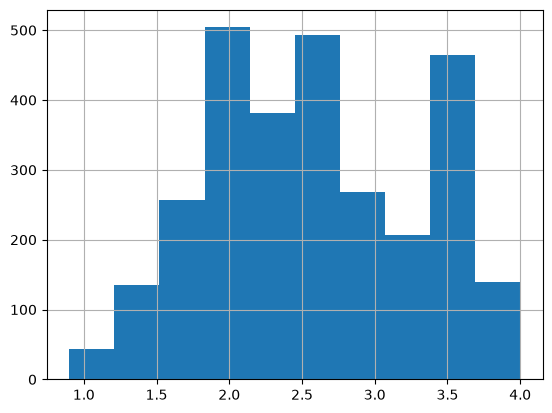

In [43]:
df["hh_sentiment_index"].hist()

In [44]:
(df["hh_sentiment_index"] == 0).sum()


np.int64(0)

In [41]:
df["worry_about_job_loss_or_economic_livelihood"].isna().sum()


np.int64(0)

Test R^2:   0.1829
Test RMSE:  0.0809
Test MAE:   0.1725


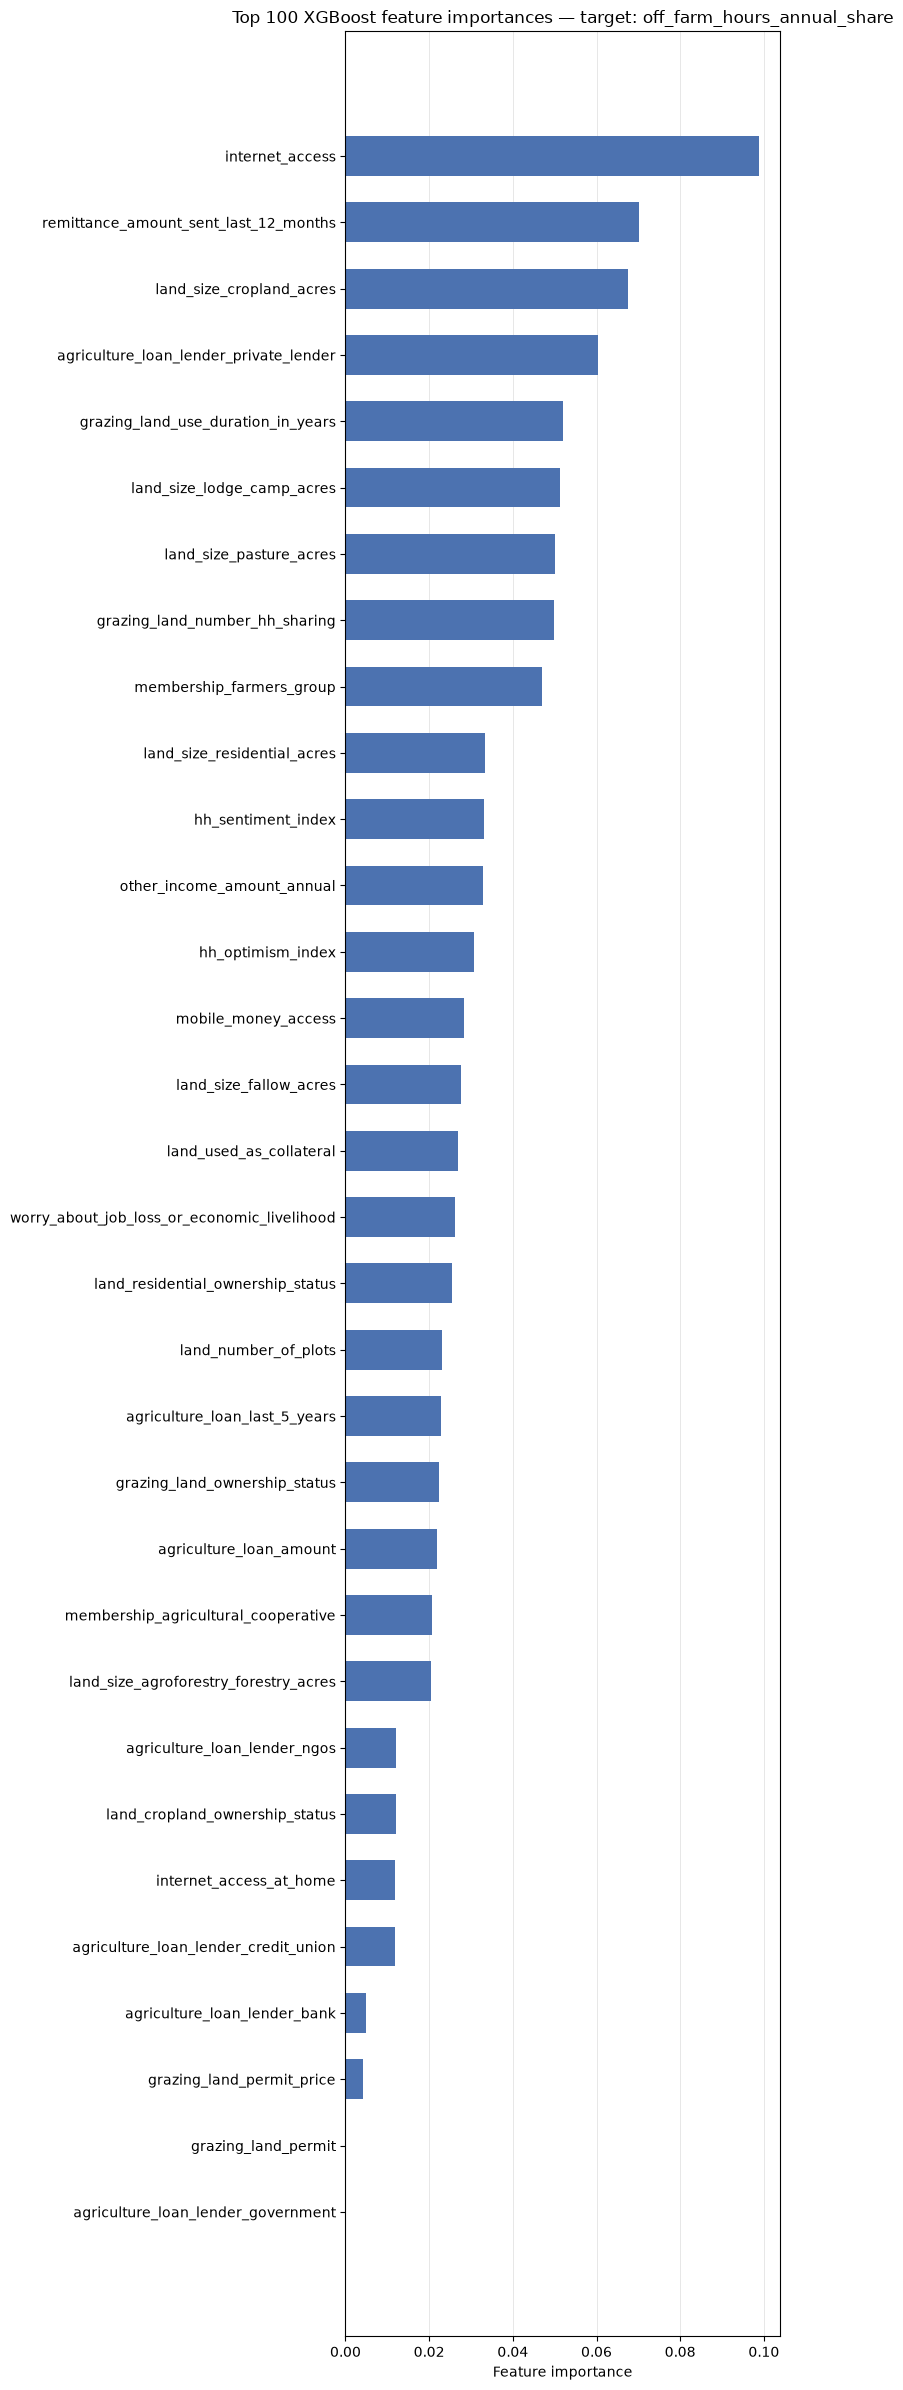

In [17]:
# --- drop columns that leak the target or don't belong as features ---
# empl_type & farm_empl_last_12_months are literally used to construct empl_category (see 02_feature_engineering.ipynb, cell c8810dc3)
# hh_members_*_share are aggregated from empl_category itself
target = 'off_farm_hours_annual_share'
df = df.dropna(subset=[target])  # can't train on unlabeled rows


y = df[target]
X = df.drop(columns=[target], errors="ignore")

# --- one-hot encode categoricals, leave everything else (incl. NaNs) as is ---
X = pd.get_dummies(X, dummy_na=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- train with standard hyperparameters ---
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)  # R^2
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test R^2:   {r2:.4f}")
print(f"Test RMSE:  {rmse:.4f}")
print(f"Test MAE:   {mae:.4f}")

# --- feature importance plot, top 100 ---
importances = pd.Series(model.feature_importances_, index=X.columns)
top100 = importances.sort_values(ascending=False).head(250)

fig, ax = plt.subplots(figsize=(8, 24))
ax.barh(top100.index[::-1], top100.values[::-1], color="#4C72B0", height=0.6)
ax.set_xlabel("Feature importance")
ax.set_title(f"Top 100 XGBoost feature importances — target: {target}")
ax.grid(axis="x", color="#dddddd", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()
